## Train LSTM on energy data

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [11]:
import rpy2.robjects as robjects

folder_name = 'energy_data'
n_states = 3

# Helper function to convert R data.frame to pandas DataFrame
def r_to_df(r_df):
    return pd.DataFrame({name: np.array(r_df.rx2(name)) for name in r_df.names})

# Read the RDS files using rpy2
readRDS = robjects.r['readRDS']
dimnames_r = robjects.r["dimnames"]

dim_names = list(dimnames_r(readRDS(folder_name + "/X_train.rds"))[2])
print("Dim names of X_train:", dim_names)

X_train_orig = np.array(readRDS(folder_name + "/X_train.rds"))
Y_train_orig = np.array(readRDS(folder_name + "/Y_train.rds"))
X_valid_orig = np.array(readRDS(folder_name + "/X_valid.rds"))
Y_valid_orig = np.array(readRDS(folder_name + "/Y_valid.rds"))
X_test_orig = np.array(readRDS(folder_name + "/X_test.rds"))
Y_test_orig = np.array(readRDS(folder_name + "/Y_test.rds"))

hmm_pred_train = np.array(readRDS(folder_name + "/Y_hat_train.rds"))
hmm_pred_valid = np.array(readRDS(folder_name + "/Y_hat_valid.rds"))
hmm_pred_test = np.array(readRDS(folder_name + "/Y_hat_test.rds"))

hmm_transition_matrix = pd.read_csv(folder_name + "/transition_matrix.csv")

last_state_test = X_test_orig[:, -1, -n_states:]
last_state_valid = X_valid_orig[:, -1, -n_states:]

X_train_orig.shape, Y_train_orig.shape, X_valid_orig.shape, Y_valid_orig.shape, X_test_orig.shape, Y_test_orig.shape

Dim names of X_train: ['log_return_VWAP', 'log_demand', 'renewable_penetration', 'gas_share', 'coal_share', 'net_export_ratio', 'net_load', 'demand_growth', 'month', 'day_of_week', 'state_prob_1', 'state_prob_2', 'state_prob_3']


((3530, 10, 13),
 (3530, 10, 3),
 (767, 10, 13),
 (767, 10, 3),
 (767, 10, 13),
 (767, 10, 3))

In [12]:
forecast_horizon = Y_train_orig.shape[1]

# Create a function to prepare data for all splits
def prepare_data_with_horizon(X, Y, shuffle=True):

    # Create one-hot encoded horizon inputs
    horizon_input = np.eye(forecast_horizon)
    horizon_input = np.repeat(horizon_input, X.shape[0], axis=0)

    # Repeat X for each forecast horizon
    X = np.concatenate([X for i in range(forecast_horizon)], axis=0)
    # Get Y for each forecast horizon
    Y = np.concatenate([Y[:, i, :] for i in range(forecast_horizon)], axis=0)
    
    # Shuffle the rows of X, horizon_input, and Y in the same order using numpy
    if shuffle:
        idx = np.random.permutation(X.shape[0])
        X = X[idx]
        horizon_input = horizon_input[idx]
        Y = Y[idx]
    return X, horizon_input, Y

# Prepare validation and test data
X_train_full, horizon_train, Y_train = prepare_data_with_horizon(X_train_orig, Y_train_orig, shuffle=True)
X_valid_full, horizon_valid, Y_valid = prepare_data_with_horizon(X_valid_orig, Y_valid_orig, shuffle=False)
X_test_full, horizon_test, Y_test = prepare_data_with_horizon(X_test_orig, Y_test_orig, shuffle=False)

X_train_full.shape, horizon_train.shape, Y_train.shape, X_valid_full.shape, horizon_valid.shape, Y_valid.shape, X_test_full.shape, horizon_test.shape, Y_test.shape

((35300, 10, 13),
 (35300, 10),
 (35300, 3),
 (7670, 10, 13),
 (7670, 10),
 (7670, 3),
 (7670, 10, 13),
 (7670, 10),
 (7670, 3))

In [13]:
X_train = X_train_full
X_valid = X_valid_full
X_test = X_test_full

### Define the model

In [14]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import keras_tuner as kt
from tensorflow.keras.losses import kullback_leibler_divergence
from tensorflow.keras.layers import Concatenate

# Assuming X_train, Y_train, X_valid, Y_valid, and n_states are defined elsewhere
# lookback and forecast_horizon are provided but not directly used in model building

# Compute Dirichlet parameters and predicted probabilities (for reference, not used in model)
def dirichlet_layer(evidence):
    alpha = evidence + 1
    S = tf.reduce_sum(alpha, axis=-1, keepdims=True)
    probs = alpha / S
    return probs, alpha, S

# Custom evidential loss with annealing
class EvidentialLoss(tf.keras.losses.Loss):
    def __init__(self, annealing_rate=100.0, max_annealing_rate=0.2, name='evidential_loss'):
        super().__init__(name=name)
        self.annealing_rate = tf.constant(annealing_rate, dtype=tf.float32)
        self.max_annealing_rate = tf.constant(max_annealing_rate, dtype=tf.float32)
        self.current_epoch = tf.Variable(0.0, trainable=False, dtype=tf.float32)
    
    def call(self, y_true, evidence):
        alpha = evidence + 1
        S = tf.reduce_sum(alpha, axis=-1, keepdims=True)
        probs = alpha / S
        
        # Classification error: categorical cross-entropy for soft probability targets
        err = tf.keras.losses.categorical_crossentropy(y_true, probs)

        var = tf.reduce_sum(probs * (1 - probs) / (S + 1), axis=-1, keepdims=True)
        
        # Annealing factor for the regularization term
        lambda_ = tf.minimum(self.max_annealing_rate, self.current_epoch / self.annealing_rate)
        
        return tf.reduce_mean(err + lambda_ * var, axis=-1)

# Custom callback to update the current epoch in the loss instance
class AnnealingCallback(tf.keras.callbacks.Callback):
    def on_epoch_begin(self, epoch, logs=None):
        if hasattr(self.model, 'loss') and isinstance(self.model.loss, EvidentialLoss):
            self.model.loss.current_epoch.assign(tf.cast(epoch, tf.float32))

# Custom metric using KL divergence
def evidential_kl_divergence(y_true, y_pred):
    probs, _, _ = dirichlet_layer(y_pred)  # Derive probabilities from evidence
    return kullback_leibler_divergence(y_true, probs)

def cross_entropy_loss(y_true, y_pred):
    probs, _, _ = dirichlet_layer(y_pred)  # Derive probabilities from evidence
    return tf.keras.losses.categorical_crossentropy(y_true, probs)

In [15]:
# Hyperparameters
lookback = 10
rnn_units = 4
dense_units = 32
dropout_rate = 0.3
embedding_dim = 4
annealing_rate = 100
max_annealing_rate = 0.1
feature_mask = tf.constant([1.0]*13, dtype=tf.float32)

In [16]:
tf.keras.backend.clear_session()

# Primary input for timeseries data
timeseries_input = layers.Input(shape=X_train.shape[1:])

# Auxiliary input for one-hot encoded horizon (length 10)
horizon_input = layers.Input(shape=(10,))

# Embed the horizon input into a dense representation
horizon_embed = layers.Dense(embedding_dim, activation='relu')(horizon_input)

# Lambda layer to slice to the last 'lookback' timesteps
sliced = layers.Lambda(lambda x: x[:, -lookback:, :])(timeseries_input)

# Lambda layer to apply feature mask (broadcast to (batch, timesteps, 20))
masked = layers.Lambda(lambda x: x * tf.reshape(feature_mask, (1, 1, X_train.shape[2])))(sliced)

# LSTM layer with added dropout
lstm_out = layers.SimpleRNN(rnn_units, dropout=dropout_rate)(masked)

# Concatenate LSTM output with embedded horizon
concat = Concatenate()([lstm_out, horizon_embed])

# Dense layers following concatenation
dense1 = layers.Dense(dense_units, activation='relu')(concat)
drop1 = layers.Dropout(dropout_rate)(dense1)
dense2 = layers.Dense(dense_units, activation='relu')(drop1)
drop2 = layers.Dropout(dropout_rate)(dense2)

# Output raw evidence (non-negative)
output = layers.Dense(n_states, activation='softplus')(drop2)

# Define the multi-input model
model = models.Model(inputs=[timeseries_input, horizon_input], outputs=output)

model.compile(
    loss=EvidentialLoss(annealing_rate=annealing_rate, max_annealing_rate=max_annealing_rate),
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    metrics=[evidential_kl_divergence, cross_entropy_loss]  # Accuracy on argmax(probs)
)

In [17]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 10, 13)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 10, 13)    │          0 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 10, 13)    │          0 │ lambda[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ simple_rnn          │ (None, 4)         │         72 │ lambda_1[0][0]    │
│ (SimpleRNN)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 4)         │         44 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 8)         │          0 │ simple_rnn[0][0], │
│ (Concatenate)       │                   │            │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │        288 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 32)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │      1,056 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 3)         │         99 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,559 (6.09 KB)

 Trainable params: 1,559 (6.09 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
import os
import random

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

os.environ['PYTHONHASHSEED'] = '0'
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'

history = model.fit(
    [X_train, horizon_train], Y_train,
    validation_data=([X_valid, horizon_valid], Y_valid),
    callbacks=[AnnealingCallback()],
    epochs=80,  # Use the same number as in your tuner setup
    verbose=1  # Set to 0 for silent output if preferred
)

Epoch 1/80


2026-03-03 19:32:11.543170: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}


1095/1104 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - cross_entropy_loss: 1.0905 - evidential_kl_divergence: 0.6829 - loss: 1.0905

2026-03-03 19:32:26.736449: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}


1104/1104 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - cross_entropy_loss: 1.0819 - evidential_kl_divergence: 0.6737 - loss: 1.0819 - val_cross_entropy_loss: 1.0550 - val_evidential_kl_divergence: 0.6028 - val_loss: 1.0550
Epoch 2/80
1104/1104 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - cross_entropy_loss: 1.0602 - evidential_kl_divergence: 0.6520 - loss: 1.0613 - val_cross_entropy_loss: 1.0335 - val_evidential_kl_divergence: 0.5813 - val_loss: 1.0345
Epoch 3/80
1104/1104 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - cross_entropy_loss: 1.0269 - evidential_kl_divergence: 0.6187 - loss: 1.0287 - val_cross_entropy_loss: 1.0017 - val_evidential_kl_divergence: 0.5495 - val_loss: 1.0034
Epoch 4/80
1104/1104 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - cross_entropy_loss: 0.9997 - evidential_kl_divergence: 0.5914 - loss: 1.0020 - val_cross_entropy_loss: 0.9927 - val_evidential_kl_divergence: 0.5405 - val_loss: 0.9950
Epoch 5/80
1104/1104 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - cross_entropy_loss: 0.9896 - evidential_kl_divergence: 0.5

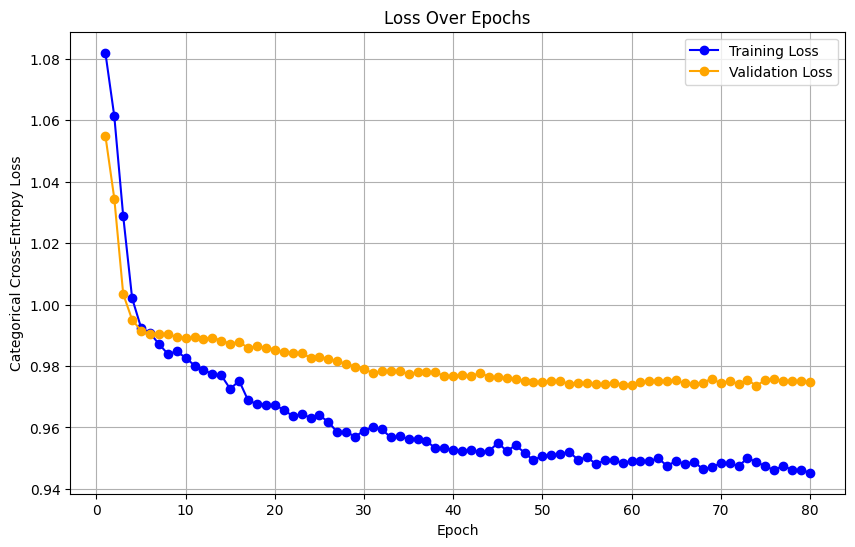

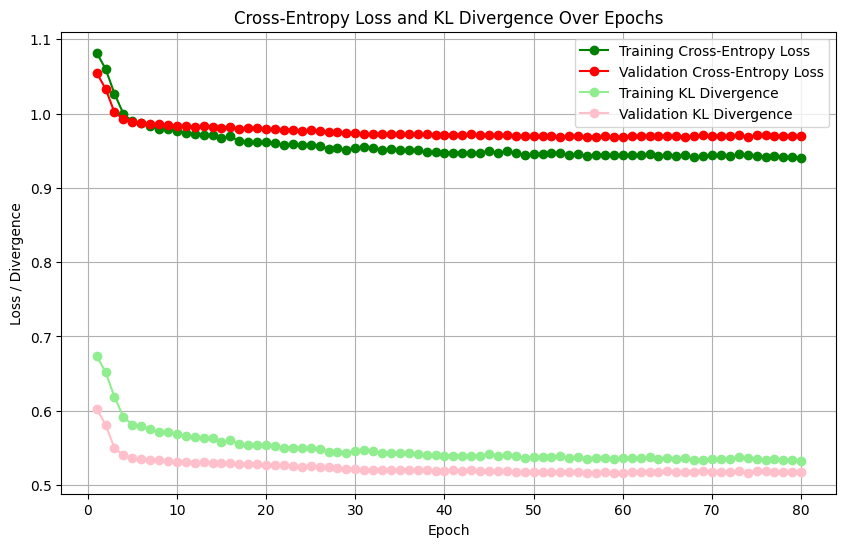

In [20]:
def plot_training_history(history):
    epochs = range(1, len(history.history['loss']) + 1)
    
    # Plot Loss
    plt.figure(figsize=(10, 6))
    plt.plot(epochs, history.history['loss'], label='Training Loss', marker='o', color='blue')
    plt.plot(epochs, history.history['val_loss'], label='Validation Loss', marker='o', color='orange')
    plt.title('Loss Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Categorical Cross-Entropy Loss')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    # Plot Accuracy
    plt.figure(figsize=(10, 6))
    plt.plot(epochs, history.history['cross_entropy_loss'], label='Training Cross-Entropy Loss', marker='o', color='green')
    plt.plot(epochs, history.history['val_cross_entropy_loss'], label='Validation Cross-Entropy Loss', marker='o', color='red')
    plt.plot(epochs, history.history['evidential_kl_divergence'], label='Training KL Divergence', marker='o', color='lightgreen')
    plt.plot(epochs, history.history['val_evidential_kl_divergence'], label='Validation KL Divergence', marker='o', color='pink')
    plt.title('Cross-Entropy Loss and KL Divergence Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss / Divergence')
    plt.legend()
    plt.grid(True)
    plt.show()
    
plot_training_history(history)

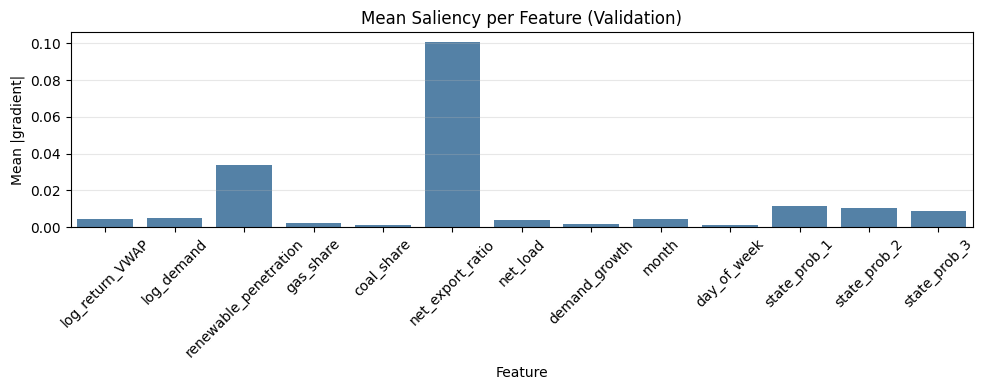

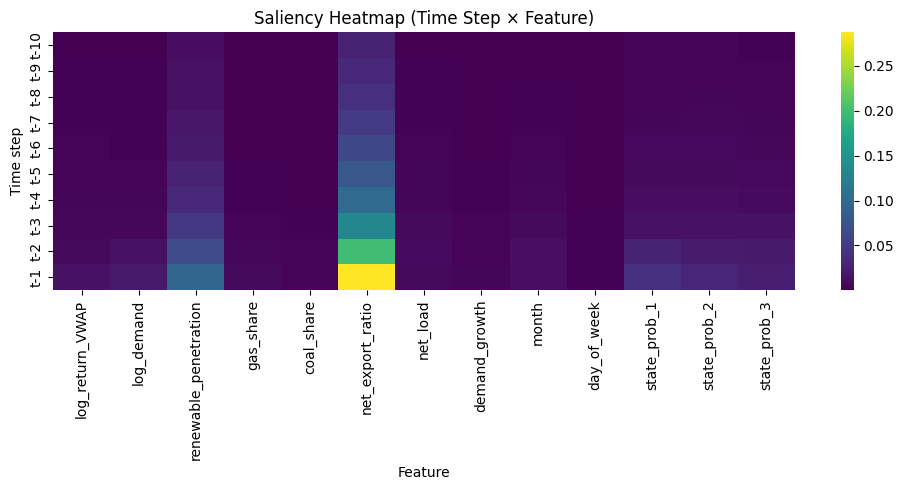

In [21]:
# Saliency map for each input feature (based on validation set)

def compute_saliency(model, X, H, Y, batch_size=256):
    saliency_batches = []
    
    for start in range(0, X.shape[0], batch_size):
        end = min(start + batch_size, X.shape[0])

        x_batch = tf.convert_to_tensor(X[start:end], dtype=tf.float32)
        h_batch = tf.convert_to_tensor(H[start:end], dtype=tf.float32)
        y_batch = tf.convert_to_tensor(Y[start:end], dtype=tf.float32)

        with tf.GradientTape() as tape:
            tape.watch(x_batch)
            evidence = model([x_batch, h_batch], training=False)
            probs, _, _ = dirichlet_layer(evidence)
            # scalar objective per sample using soft labels
            score = tf.reduce_sum(probs * y_batch, axis=1)

        grads = tape.gradient(score, x_batch)  # (batch, time, features)
        saliency_batches.append(tf.abs(grads).numpy())

    saliency = np.concatenate(saliency_batches, axis=0)
    return saliency

# Compute saliency on validation flattened set
saliency_valid = compute_saliency(model, X_valid, horizon_valid, Y_valid)

# Aggregate saliency
feature_saliency = saliency_valid.mean(axis=(0, 1))   # (features,)
time_feature_saliency = saliency_valid.mean(axis=0)   # (time, features)

feature_names = dim_names

# Plot 1: saliency by feature
plt.figure(figsize=(10, 4))
sns.barplot(x=feature_names, y=feature_saliency, color="steelblue")
plt.title("Mean Saliency per Feature (Validation)")
plt.ylabel("Mean |gradient|")
plt.xlabel("Feature")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 2: time-feature saliency heatmap
plt.figure(figsize=(10, 5))
sns.heatmap(
    time_feature_saliency,
    cmap="viridis",
    xticklabels=feature_names,
    yticklabels=[f"t-{X_valid.shape[1]-i}" for i in range(X_valid.shape[1])]
)
plt.title("Saliency Heatmap (Time Step × Feature)")
plt.xlabel("Feature")
plt.ylabel("Time step")
plt.tight_layout()
plt.show()

# Get test statistics

In [23]:
Y_test.shape

(7670, 3)

In [24]:
Y_test_reshaped = Y_test.reshape(forecast_horizon, -1, n_states).transpose(1, 0, 2)
hmm_loss = -np.sum(Y_test_reshaped * np.log(np.clip(hmm_pred_test, 1e-15, 1.0)), axis=2)
hmm_stats_test = pd.DataFrame({
    'mean': np.nanmean(hmm_loss, axis=0),
    'median': np.nanmedian(hmm_loss, axis=0),
    'P25': np.nanpercentile(hmm_loss, 25, axis=0),
    'P75': np.nanpercentile(hmm_loss, 75, axis=0),
    'max': np.nanmax(hmm_loss, axis=0),
    'min': np.nanmin(hmm_loss, axis=0)
})

def test_results(model, X, horizon, Y):
    Y_hat = model.predict([X, horizon])

    probs, alpha, S = dirichlet_layer(Y_hat)
    probs = probs.numpy()
    S = S.numpy()

    probs_reshaped = probs.reshape(forecast_horizon, -1, n_states).transpose(1, 0, 2)
    S_reshaped = S.reshape(forecast_horizon, -1).T

    Y_reshaped = Y.reshape(forecast_horizon, -1, n_states).transpose(1, 0, 2)

    loss = -np.sum(Y * np.log(np.clip(probs, 1e-15, 1.0)), axis=1)
    loss_reshaped = loss.reshape(forecast_horizon, -1).T

    stats = pd.DataFrame({
        'mean': np.nanmean(loss_reshaped, axis=0),
        'median': np.nanmedian(loss_reshaped, axis=0),
        'P25': np.nanpercentile(loss_reshaped, 25, axis=0),
        'P75': np.nanpercentile(loss_reshaped, 75, axis=0),
        'max': np.nanmax(loss_reshaped, axis=0),
        'min': np.nanmin(loss_reshaped, axis=0)
    })

    return probs_reshaped, S_reshaped, loss_reshaped, stats, Y_reshaped

probs_valid, S_valid, loss_valid, stats_valid, Y_valid_reshaped = test_results(model, X_valid, horizon_valid, Y_valid)
probs_test, S_test, loss_test, stats_test, Y_test_reshaped = test_results(model, X_test, horizon_test, Y_test)

stats_test

 20/240 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step   

2026-03-03 19:45:35.546127: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


,mean,median,P25,P75,max,min
0,1.127343,0.966721,0.765025,1.389947,2.844971,0.589320
1,1.119388,0.978216,0.786369,1.364347,2.738456,0.613579
2,1.120368,0.977286,0.800617,1.384092,2.684419,0.621760
3,1.122341,0.992012,0.812947,1.372203,2.484113,0.637965
4,1.106589,0.988483,0.819866,1.341376,2.384419,0.630822
5,1.113136,0.998962,0.819023,1.378641,2.467069,0.626738
6,1.120152,1.004352,0.827533,1.370646,2.418398,0.631482
7,1.118030,0.994874,0.824989,1.366289,2.318130,0.628647
8,1.113404,0.984807,0.820416,1.362120,2.564745,0.622569
9,1.118060,0.991217,0.822130,1.355009,2.524699,0.636882


In [25]:
hmm_stats_test

,mean,median,P25,P75,max,min
0,0.708555,0.686440,0.461953,0.838084,2.653722,0.208346
1,0.788895,0.749743,0.587234,0.890517,2.236656,0.385721
2,0.836722,0.786048,0.679214,0.912519,2.133261,0.533622
3,0.869290,0.814400,0.734834,0.941566,2.029643,0.619037
4,0.895240,0.835542,0.780443,0.957570,1.894566,0.662532
5,0.917369,0.868567,0.827665,0.978121,1.908702,0.696277
6,0.936789,0.899401,0.849294,0.993299,1.863248,0.719865
7,0.953377,0.943615,0.861695,1.013306,1.815011,0.741949
8,0.968510,0.967684,0.876990,1.034828,1.752421,0.757585
9,0.981860,0.990417,0.888075,1.051104,1.685323,0.770449


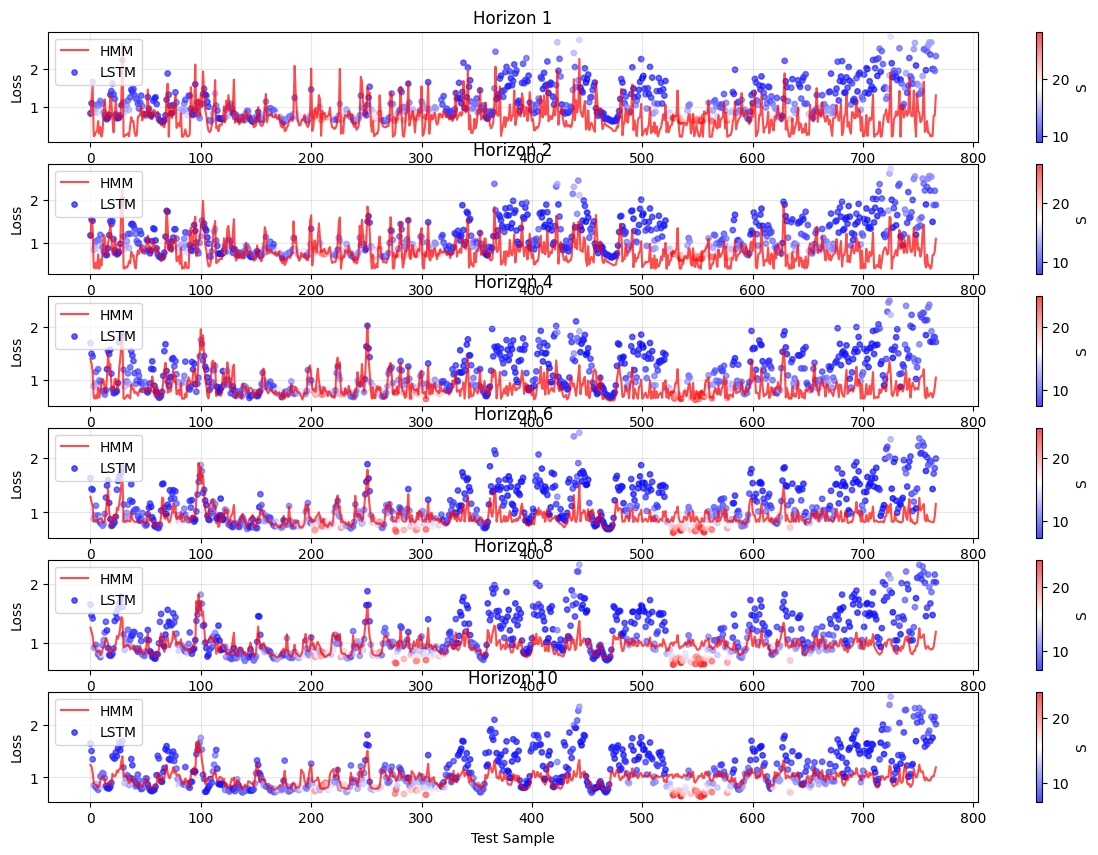

In [29]:
# Horizon indices (0-based): 0, 1, 3
horizons = [0, 1, 3, 5, 7, 9]
titles = ['Horizon 1', 'Horizon 2', 'Horizon 4', 'Horizon 6', 'Horizon 8', 'Horizon 10']

plt.figure(figsize=(15, 10))

for i, horizon in enumerate(horizons):
    ax = plt.subplot(len(horizons), 1, i + 1)
    ax.plot(hmm_loss[:, horizon], label='HMM', color='red', alpha=0.7)
    sc = ax.scatter(
        x=range(len(loss_test[:, horizon])),
        y=loss_test[:, horizon],
        c=(S_test[:, horizon]),   # color by S_reshaped values
        cmap='bwr',
        alpha=0.7,
        s=15,
        label='LSTM'
    )
    plt.colorbar(sc, ax=ax, label='S')
    ax.set_title(titles[i])
    ax.set_xlabel('Test Sample')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

In [30]:
# Correlation between uncertainty mass (S_reshaped) and loss (loss_reshaped)
loss_diff = hmm_loss - loss_test # Element-wise difference

# Overall (all horizons pooled)
overall_pearson = np.corrcoef(S_test.ravel(), loss_diff.ravel())[0, 1]

# Per-horizon Pearson correlation
corr_by_horizon = [
    np.corrcoef(S_test[:, h].ravel(), loss_diff[:, h].ravel())[0, 1]
    for h in range(forecast_horizon)
]

corr_df = pd.DataFrame({
    "horizon": np.arange(1, forecast_horizon + 1),
    "pearson_corr_S_vs_loss": corr_by_horizon
})

print(f"Overall Pearson correlation (S vs loss): {overall_pearson:.4f}")
corr_df

Overall Pearson correlation (S vs loss): 0.3439


,horizon,pearson_corr_S_vs_loss
0,1,0.270330
1,2,0.313570
2,3,0.362451
3,4,0.433305
4,5,0.479602
5,6,0.514239
6,7,0.537026
7,8,0.539915
8,9,0.525307
9,10,0.537239


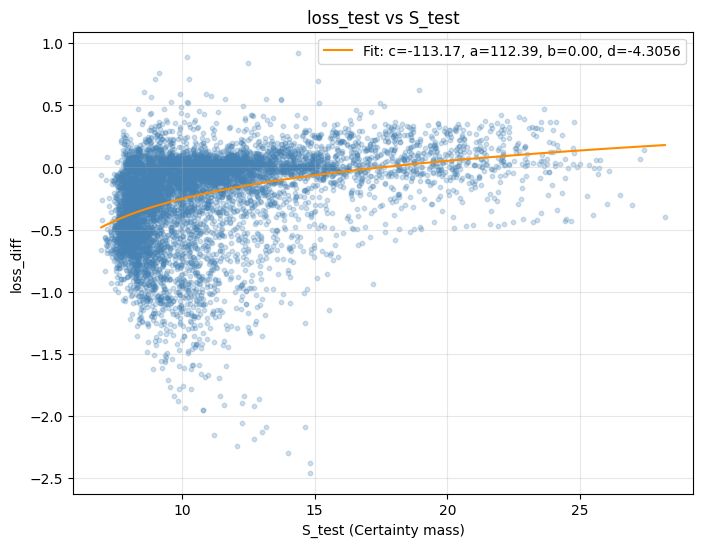

In [31]:
from scipy.optimize import curve_fit

# Scatter plot of loss_test vs S_test (all horizons pooled)
plt.figure(figsize=(8, 6))
plt.scatter(S_test.ravel(), loss_diff.ravel(), alpha=0.25, s=10, color='steelblue')
plt.xlabel('S_test (Certainty mass)')
plt.ylabel('loss_diff')
plt.title('loss_test vs S_test')
plt.grid(True, alpha=0.3)

# Optional power-law trend line with intercept: y = c + a * x^b
x = S_test.ravel().astype(float)
y = loss_diff.ravel().astype(float)

# Model: y = c + a*(x + d)^b
def shifted_power(x, c, a, b, d):
    return c + a * np.power(x + d, b)
  
# Keep only finite points
mask = np.isfinite(x) & np.isfinite(y)
x_fit, y_fit = x[mask], y[mask]

# Initial guesses
c0 = np.percentile(y_fit, 5)
a0 = np.percentile(y_fit, 95) - c0
b0 = 1.0
d0 = max(1e-3, -np.min(x_fit) + 1e-3)  # ensures x+d > 0 at start

# Bounds: enforce valid power input and reasonable shape
lower = [-np.inf, -np.inf, -5.0, -np.min(x_fit) + 1e-8]
upper = [ np.inf,  np.inf,  5.0,  np.inf]

popt, pcov = curve_fit(
    shifted_power, x_fit, y_fit,
    p0=(c0, a0, b0, d0),
    bounds=(lower, upper),
    maxfev=50000
)

c_hat, a_hat, b_hat, d_hat = popt
x_line = np.linspace(np.min(x_fit), np.max(x_fit), 100)
y_line = shifted_power(x_line, c_hat, a_hat, b_hat, d_hat)
plt.plot(x_line, y_line, color='darkorange', label=f'Fit: c={c_hat:.2f}, a={a_hat:.2f}, b={b_hat:.2f}, d={d_hat:.4f}')
plt.legend()

plt.show()

In [32]:
transition_matrix = hmm_transition_matrix.drop(columns=['Unnamed: 0'])
transition_matrix = transition_matrix.rename(columns={'state.1.1': 0, 'state.2.1': 1, 'state.3.1': 2})

alpha = 0.3
def hybrid_model(probs_reshaped, S_reshaped, transition_matrix, alpha_0, alpha_1, last_state, Y_reshaped):

    S_scaled = (S_reshaped - np.min(S_reshaped)) / (np.max(S_reshaped) - np.min(S_reshaped))
    alpha = alpha_0 + alpha_1 * S_scaled
    alpha = np.clip(alpha, 0.0, 1.0)

    trials = probs_reshaped.shape[0]
    horizons = probs_reshaped.shape[1]
    combined_transitions = np.zeros((trials, horizons, n_states, n_states))
    for trial in range(trials):
        for horizon in range(horizons):
            #_alpha = (alpha + 0) / (horizon + 0 + 1)
            _alpha = alpha[trial, horizon]
            combined = np.tile(probs_reshaped[trial, horizon, :], (n_states, 1)) * _alpha + transition_matrix * (1 - _alpha)
            combined_transitions[trial, horizon, :, :] = combined

    hybrid_predictions = np.zeros((trials, horizons, n_states))
    for trial in range(trials):
        for horizon in range(horizons):
            if horizon == 0:
                last_prediction = last_state[trial, :]
            else:
                last_prediction = hybrid_predictions[trial, horizon - 1, :]
            next_prediction = last_prediction @ combined_transitions[trial, horizon, :, :]
            hybrid_predictions[trial, horizon, :] = next_prediction

    eps = 1e-15
    hybrid_state_loss = -np.sum(
        Y_reshaped * np.log(np.clip(hybrid_predictions, eps, 1.0)),
        axis=2
    )

    return hybrid_predictions, hybrid_state_loss

In [33]:
n_0 = 10
n_1 = 10
min_alpha_0 = 0
max_alpha_0 = 1
min_alpha_1 = 0
max_alpha_1 = 1
valid = False
alpha_stats = {'alpha_0': np.zeros((n_0,n_1)), 'alpha_1': np.zeros((n_0,n_1)), 'min_loss': np.zeros((n_0,n_1)), 
               '25 percentile': np.zeros((n_0,n_1)), 'mean_loss': np.zeros((n_0,n_1)), 
               '75 percentile': np.zeros((n_0,n_1)), 'max_loss': np.zeros((n_0,n_1))}
for i, alpha_0 in enumerate(np.linspace(min_alpha_0, max_alpha_0, n_0)):
    for j, alpha_1 in enumerate(np.linspace(min_alpha_1, max_alpha_1, n_1)):
        if valid:
            probs = probs_valid
            S = S_valid
            last_state = last_state_valid
            Y_reshaped = Y_valid_reshaped
        else:
            probs = probs_test
            S = S_test
            last_state = last_state_test
            Y_reshaped = Y_test_reshaped
        predictions, loss = hybrid_model(
            probs, S,
            transition_matrix,
            alpha_0, alpha_1, 
            last_state, 
            Y_reshaped)
        alpha_stats['alpha_0'][i, j] = alpha_0
        alpha_stats['alpha_1'][i, j] = alpha_1
        alpha_stats['min_loss'][i, j] = np.min(loss)
        alpha_stats['25 percentile'][i, j] = np.percentile(loss, 25)
        alpha_stats['mean_loss'][i, j] = np.mean(loss)
        alpha_stats['75 percentile'][i, j] = np.percentile(loss, 75)
        alpha_stats['max_loss'][i, j] = np.max(loss) 

In [34]:
min_idx = np.unravel_index(np.argmin(alpha_stats['mean_loss']), alpha_stats['mean_loss'].shape)
min_idx

(np.int64(0), np.int64(0))

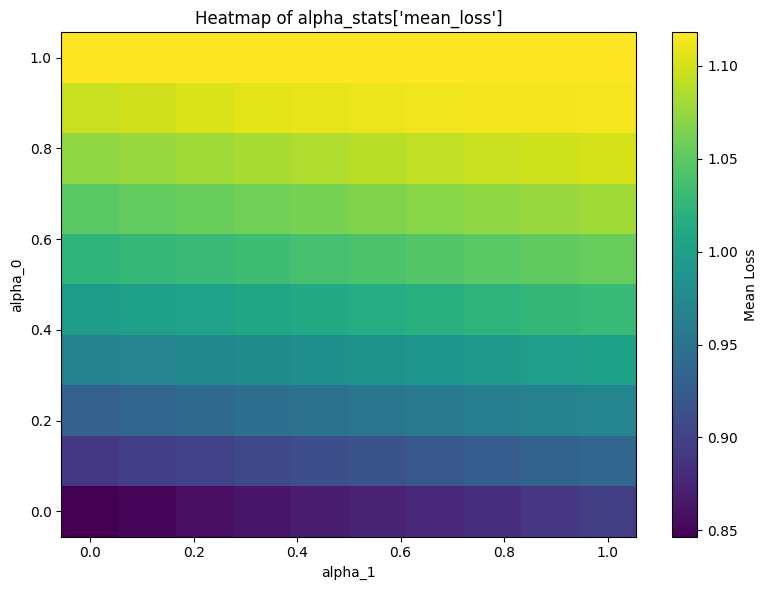

In [35]:
alpha_0_vals = np.linspace(min_alpha_0, max_alpha_0, n_0)
alpha_1_vals = np.linspace(min_alpha_1, max_alpha_1, n_1)

plt.figure(figsize=(8, 6))
pcm = plt.pcolormesh(
    alpha_1_vals,
    alpha_0_vals,
    alpha_stats['mean_loss'],
    shading='auto',
    cmap='viridis'
)
plt.colorbar(pcm, label='Mean Loss')

plt.title("Heatmap of alpha_stats['mean_loss']")
plt.xlabel('alpha_1')
plt.ylabel('alpha_0')
#plt.xlim(alpha_1_vals.min(), alpha_1_vals.max())
#plt.ylim(alpha_0_vals.min(), alpha_0_vals.max())
# plt.axvline(x=0, color='red', linestyle='-', linewidth=1.5)
# plt.axhline(y=0, color='red', linestyle='-', linewidth=1.5)

plt.tight_layout()
plt.show()

In [36]:
# Compute statistics for each column of lstm_state_losses
hybrid_predictions_test, hybrid_loss_test = hybrid_model(
    probs_reshaped=probs_test,
    S_reshaped=S_test,
    transition_matrix=transition_matrix, 
    alpha_0=0, 
    alpha_1=0.1, 
    last_state=last_state_test, 
    Y_reshaped=Y_test_reshaped)
hybrid_loss_df = pd.DataFrame({
    'mean': np.nanmean(hybrid_loss_test, axis=0),
    'median': np.nanmedian(hybrid_loss_test, axis=0),
    'P25': np.nanpercentile(hybrid_loss_test, 25, axis=0),
    'P75': np.nanpercentile(hybrid_loss_test, 75, axis=0),
    'max': np.nanmax(hybrid_loss_test, axis=0),
    'min': np.nanmin(hybrid_loss_test, axis=0)
})
hybrid_loss_df

,mean,median,P25,P75,max,min
0,0.700392,0.687971,0.479593,0.844128,2.112570,0.187754
1,0.773581,0.747487,0.606775,0.912489,2.233032,0.341646
2,0.814303,0.789763,0.680196,0.925232,2.295223,0.453487
3,0.841925,0.815514,0.728984,0.920647,2.157419,0.541883
4,0.862670,0.838357,0.743123,0.931829,2.047563,0.602893
5,0.879315,0.856856,0.758711,0.948639,1.922017,0.654505
6,0.893339,0.856310,0.773815,0.973886,1.837887,0.679576
7,0.904828,0.868539,0.777987,0.994297,1.761105,0.696551
8,0.914684,0.882548,0.785799,1.011597,1.688722,0.706258
9,0.923229,0.887038,0.793270,1.027141,1.612114,0.717601


/tmp/ipykernel_3299633/2864698278.py:41: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


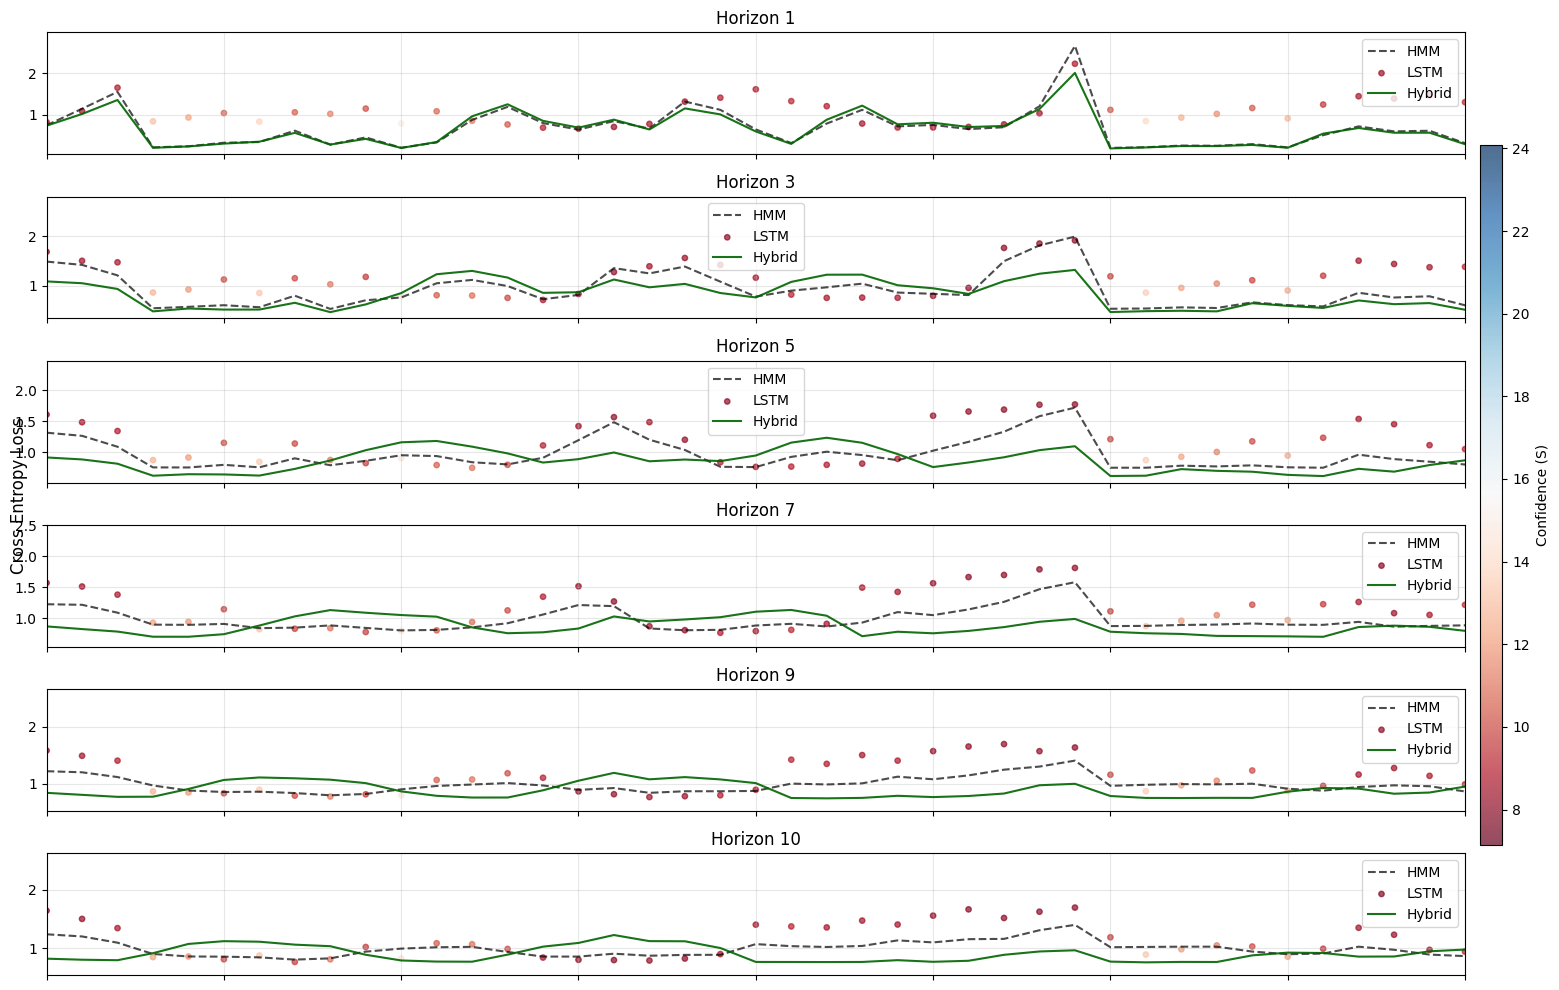

In [38]:
plt.figure(figsize=(15, 10))

horizons = [0, 2, 4, 6, 8, 9]
titles = ['Horizon 1', 'Horizon 3', 'Horizon 5', 'Horizon 7', 'Horizon 9', 'Horizon 10']
xlimits = [0, 40]

for i, horizon in enumerate(horizons):
    ax = plt.subplot(len(horizons), 1, i + 1)
    ax.plot(hmm_loss[:, horizon], label='HMM', color='black', linestyle='--', alpha=0.7)
    sc = ax.scatter(
        x=range(len(loss_test[:, horizon])),
        y=loss_test[:, horizon],
        c=(S_test[:, horizon]),   # color by S_reshaped values
        cmap='RdBu',
        alpha=0.7,
        s=15,
        label='LSTM'
    )
    #plt.colorbar(sc, ax=ax, label='Confidence (S)')
    ax.plot(hybrid_loss_test[:, horizon], label='Hybrid', color='darkgreen', alpha=0.9)
    ax.set_title(titles[i])
    if i == 0:
        plt.gcf().supylabel('Cross Entropy Loss')
    ax.set_yscale('linear')
    ax.set_xticklabels([])
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xlim(xlimits[0], xlimits[1])
    #ax.set_ylim(0, 6)
    # if i == len(horizons) - 1:
    #     tick_idx = np.arange(0, min(len(date_list), xlimits[1] + 1), 10)
    #     ax.set_xticks(tick_idx)
    #     ax.set_xticklabels([date_list[k].strftime("%Y-%m-%d") for k in tick_idx], rotation=0, ha='center')

fig = plt.gcf()
fig.subplots_adjust(right=0.88)  # leave room for colorbar on the right

if 'sc' in locals():
    cax = fig.add_axes([1, 0.15, 0.015, 0.7])  # [left, bottom, width, height]
    fig.colorbar(sc, cax=cax, label='Confidence (S)')
plt.tight_layout()
plt.show()